In this notebook we recreate the plots that were presented in 'Cosmological perturbations with ultralight vector dark matter fields: numerical implementation in CLASS'.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from classy import Class
from scipy.interpolate import interp1d
import copy

plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'serif'

### LCDM

In [2]:
# Planck 2018  Cosmological parameters

h_planck = 0.6688              # TT,TE,EE+lowE
omega_m = 0.321*h_planck**2   # TT,TE,EE+lowE
omega_cdm = 0.1206            # TT,TE,EE+lowE
Omega_Lambda = 0.679          # TT,TE,EE+lowE
omega_b = 0.02212              # TT,TE,EE+lowE
tau_reio = 0.05522              # TT,TE,EE+lowE
As = 2.092 * 1.e-9             # TT,TE,EE+lowE
ns = 0.962                    # TT,TE,EE+lowE
theta_s = 1.04077              # TT,TE,EE+lowE


In [3]:
colors = ['r', 'b', 'g', 'm', 'y']
k_out = [0.01, 0.1, 1]  # 1/Mpc    Los k tienen que estar en unidades de 1/Mpc para estas funciones.
mass = 1.e-25 # eV

# Precision overrides (previously hard-coded in include/precisions.h, now set per-notebook)
precision_settings = {
    'start_small_k_at_tau_c_over_tau_h': 0.0004,
    'start_large_k_at_tau_h_over_tau_k': 0.001,
    'tol_perturbations_integration': 1.e-6
}

lcdm_settings = {'omega_b':omega_b,'Omega_cdm':omega_cdm/h_planck**2,'100*theta_s': theta_s,'ln10^{10}A_s' : As
                 ,'n_s':ns,'tau_reio':tau_reio,
                 'YHe': 'BBN','output':'tCl mPk','gauge':'synchronous',
                  'format': 'camb', 'ic' : 'ad','P_k_ini type' : 'analytic_Pk', 
                  'Omega_k' : 0., 'N_ncdm' : 0, 'k_output_values':str(k_out).strip('[]')}
lcdm_settings.update(precision_settings)

lcdm = Class()
lcdm.set(lcdm_settings)
lcdm.compute()
perturbations_lcdm = copy.deepcopy(lcdm.get_perturbations())
background_lcdm    = copy.deepcopy(lcdm.get_background())
lcdm.struct_cleanup()
lcdm.empty()

common_settings  = {
            'output':'tCl mPk',
            'h' : h_planck,
            'Omega_cdm': 0,
            'omega_b' : omega_b,
            'Omega_dcdmdr' : 0.0,
            'N_ncdm' : 0,
            'Omega_k' : 0.,
            'Omega_fld' : 0.,
            'Omega_vf' : omega_cdm/h_planck**2,
            'attractor_ic_vf' : 'yes',
            'svt_coupling' : 'no',
            'YHe' : 'BBN',
            'tau_reio':tau_reio,
            'output' : 'tCl',
            'k_output_values':str(k_out).strip('[]'),
            'ic' : 'ad',
            'gauge' : 'synchronous',
            'P_k_ini type' : 'analytic_Pk',
            'A_s' : As,
            'n_s' : ns,
            'format': 'camb',
            'vector_background_mode': 'bianchi'
            }
common_settings.update(precision_settings)

## $\theta_k$ sweep 

### $k = 10 \,Mpc{-1}$ 

In [4]:
k_in_h = 10
mass = 1.e-25
k = k_in_h*0.67556
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']

lcdm = Class()
lcdm.set(lcdm_settings)
lcdm.set({'k_output_values':str(k)})
lcdm.compute()
perturbations_lcdm = copy.deepcopy(lcdm.get_perturbations())
background_lcdm    = copy.deepcopy(lcdm.get_background())
lcdm.struct_cleanup()
lcdm.empty()

perts = {}
for m in range(len(angles)):
    M = Class()
    M.set(common_settings)
    M.set({'gamma_Ak' : angles[m]})
    M.set({'vf_mass' : '%s'%mass})
    M.set({'k_output_values':str(k)})
    M.compute()
    perts[m] = copy.deepcopy(M.get_perturbations())
    M.struct_cleanup()
    M.empty()
    print(angles[m])

0
0.39269908169872414
0.7853981633974483
1.5707963267948966


In [5]:
data_scf = np.loadtxt('../../SFDM_data/delta_scf/delta_scf_m={-25}_k=10')

a_scf = data_scf[:,0]  # first column
delta_scf = data_scf[:,1]  # second column

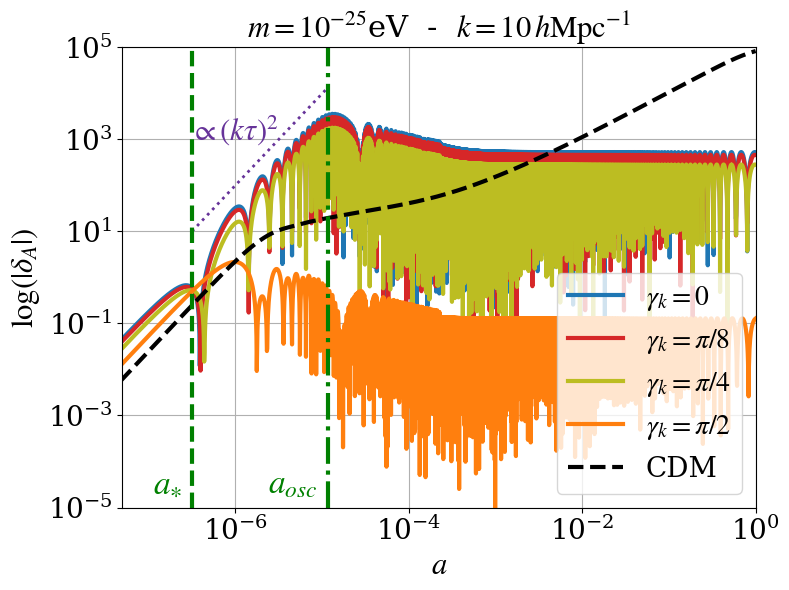

In [6]:
# DELTA  k = 10

plt.figure(figsize=(8, 6))
for i in range(len(angles)):

    one_k = perts[i]['scalar'][0]
    one_k_lcdm = perturbations_lcdm['scalar'][0]
    delta_vf = one_k['delta_vf']
    delta_lcdm = one_k_lcdm['delta_cdm']
    a = one_k['a']
    a_lcdm = one_k_lcdm['a']
    h = h_planck # get reduced Hubble for conversions to 1/Mpc
    background_z = background_lcdm['z'] # read redshift
    background_a = 1/(1+background_z)
    rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
    mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
    a_equality = interp1d(mat_abundance/rad_abundance, background_a)
    a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)
    a_of_a = interp1d(a, a)

    background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
    background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
    background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 
    tau_of_a = interp1d(background_a, background_lcdm['conf. time [Mpc]'])
    k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
    k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
    k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

    plt.xlabel(r'$a$', size=22)
    plt.ylabel(r'$\log(|\delta_A|)$', size=22)
    plt.loglog(a, np.abs(delta_vf), color=color_angles[i], label=r'$\gamma_{k}=%s$'% str(angles_label[i]), lw=3)
plt.loglog(a_lcdm, np.abs(delta_lcdm), 'k--', label=r'CDM', lw=3)
a_range = np.linspace(a_of_a(k_over_aH), a_of_a(a_osc), 10)
plt.loglog(a_range, np.pow(k*(tau_of_a(a_range)),2)*10, 'rebeccapurple', linestyle=':', lw=2)
plt.vlines(k_over_aH, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashdot',lw=3)
plt.text(0.2*a_osc, 2*1.e-5, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.text(0.35*k_over_aH, 2*1.e-5, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.text(3.e-7, 1.e3, r'$\propto(k\tau)^2$', fontdict={'color':'rebeccapurple', 'fontweight':'bold'}, size=22)
plt.legend(loc='lower right', fontsize=20)
plt.grid()
plt.title(r'$m = 10^{-25}$eV  -  $k = 10\, h \rm{Mpc}^{-1}$', fontsize=22)
plt.ylim(1.e-5, 1.e5)
plt.xlim(5.e-8, 1)
plt.tick_params(axis='both',labelsize=20)
plt.tight_layout()
plt.savefig('../../Figures/delta_A_angles_m=%s_k=%s.pdf'%(str(mass)[-3:],str(k_in_h)))
plt.savefig('../../Figures/delta_A_angles_m=%s_k=%s.png'%(str(mass)[-3:],str(k_in_h)))
plt.show()

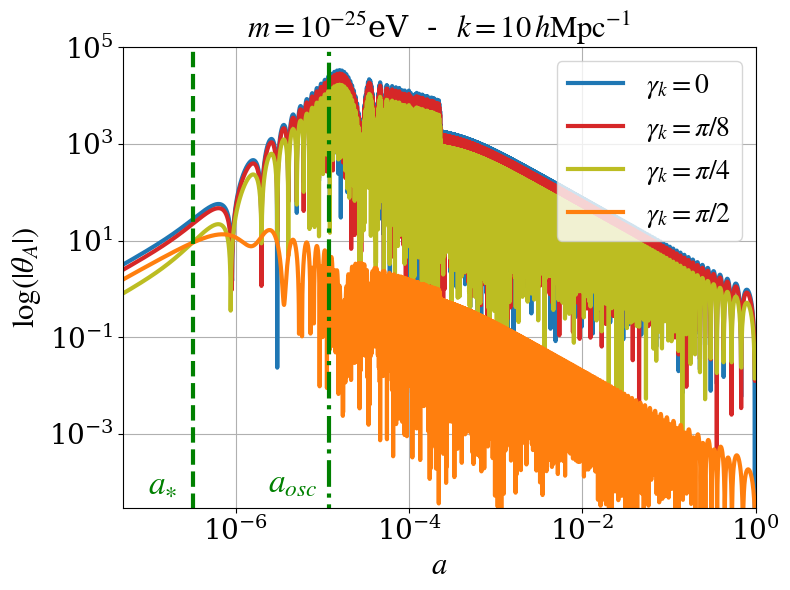

In [7]:
# THETA  k = 10
plt.figure(figsize=(8, 6))
for i in range(len(angles)):

    one_k = perts[i]['scalar'][0]
    one_k_lcdm = perturbations_lcdm['scalar'][0]
    theta_vf = one_k['theta_vf']
    a = one_k['a']
    a_lcdm = one_k_lcdm['a']
    h = h_planck # get reduced Hubble for conversions to 1/Mpc
    background_z = background_lcdm['z'] # read redshift
    background_a = 1/(1+background_z)
    rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
    mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
    a_equality = interp1d(mat_abundance/rad_abundance, background_a)
    a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)

    background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
    background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
    background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 

    k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
    k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
    k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

    plt.xlabel(r'$a$', size=22)
    plt.ylabel(r'$\log(|\theta_A|)$', size=22)
    plt.loglog(a, np.abs(theta_vf), color=color_angles[i], label=r'$\gamma_{k}=%s$'% str(angles_label[i]), lw=3)
plt.vlines(k_over_aH, ymin=1.e-5, ymax=3*1.e5,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-5, ymax=3*1.e5,color='g',linestyle='dashdot',lw=3)
plt.text(0.2*a_osc, 6.e-5, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.text(0.3*k_over_aH, 6*1.e-5, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.legend(loc='upper right', fontsize=20)
plt.grid()
plt.ylim(3*1.e-5, 1.e5)
plt.title(r'$m = 10^{-25}$eV  -  $k = 10 \,h \rm{Mpc}^{-1}$', fontsize=22)
plt.xlim(5.e-8, 1)
plt.tick_params(axis='both',labelsize=20)
plt.tight_layout()
plt.savefig('../../Figures/theta_A_m=-25_k=10.pdf')
plt.show()

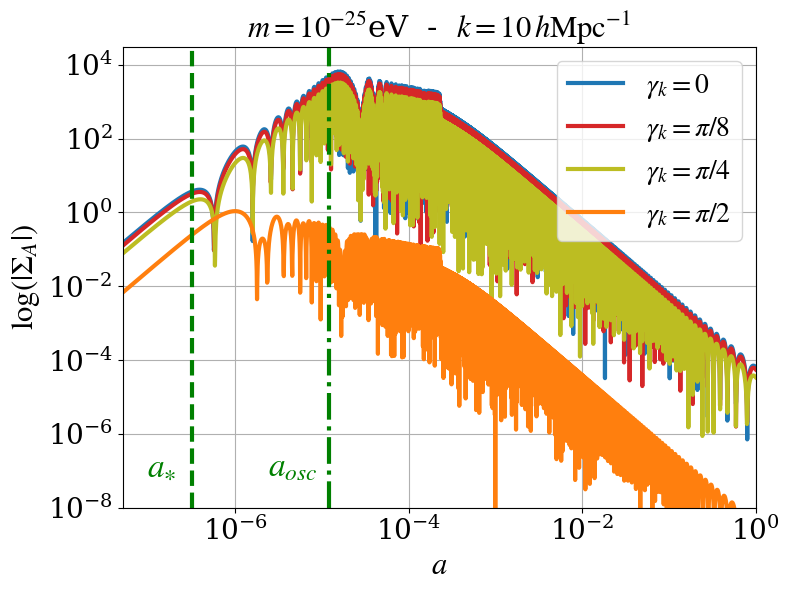

In [8]:
# THETA  k = 10
plt.figure(figsize=(8, 6))
for i in range(len(angles)):

    one_k = perts[i]['scalar'][0]
    one_k_lcdm = perturbations_lcdm['scalar'][0]
    shear_vf = one_k['shear_vf']
    a = one_k['a']
    a_lcdm = one_k_lcdm['a']
    h = h_planck # get reduced Hubble for conversions to 1/Mpc
    background_z = background_lcdm['z'] # read redshift
    background_a = 1/(1+background_z)
    rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
    mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
    a_equality = interp1d(mat_abundance/rad_abundance, background_a)
    a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)

    background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
    background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
    background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 

    k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
    k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
    k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

    plt.xlabel(r'$a$', size=22)
    plt.ylabel(r'$\log(|\Sigma_A|)$', size=22)
    plt.loglog(a, np.abs(shear_vf), color=color_angles[i], label=r'$\gamma_{k}=%s$'% str(angles_label[i]), lw=3)
plt.vlines(k_over_aH, ymin=1.e-8, ymax=3*1.e5,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-8, ymax=3*1.e5,color='g',linestyle='dashdot',lw=3)
plt.text(0.2*a_osc, 7.e-8, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.text(0.3*k_over_aH, 7.e-8, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.legend(loc='upper right', fontsize=20)
plt.grid()
plt.ylim(1.e-8, 3.e4)
plt.xlim(5.e-8, 1)
plt.tick_params(axis='both',labelsize=20)
plt.title(r'$m = 10^{-25}$eV  -  $k = 10 \,h \rm{Mpc}^{-1}$', fontsize=22)
plt.tight_layout()
plt.savefig('../../Figures/shear_A_m=-25_k=10.pdf')
plt.show()

### $k = 0.1 \,Mpc{-1}$ 

In [9]:
k_in_h = 0.1
mass = 1.e-25
k = k_in_h*0.67556
angles = [0, np.pi/8, np.pi/4, np.pi/2]
angles_label = ['0', 'π/8', 'π/4', 'π/2']
color_angles = ['tab:blue','tab:red','tab:olive','tab:orange']

lcdm = Class()
lcdm.set(lcdm_settings)
lcdm.set({'k_output_values':str(k)})
lcdm.compute()
perturbations_lcdm = copy.deepcopy(lcdm.get_perturbations())
background_lcdm    = copy.deepcopy(lcdm.get_background())
lcdm.struct_cleanup()
lcdm.empty()

perts = {}
for m in range(len(angles)):
    M = Class()
    M.set(common_settings)
    M.set({'gamma_Ak' : angles[m]})
    M.set({'vf_mass' : '%s'%mass})
    M.set({'k_output_values':str(k)})
    M.compute()
    perts[m] = copy.deepcopy(M.get_perturbations())
    M.struct_cleanup()
    M.empty()
    print(angles[m])

0
0.39269908169872414
0.7853981633974483
1.5707963267948966


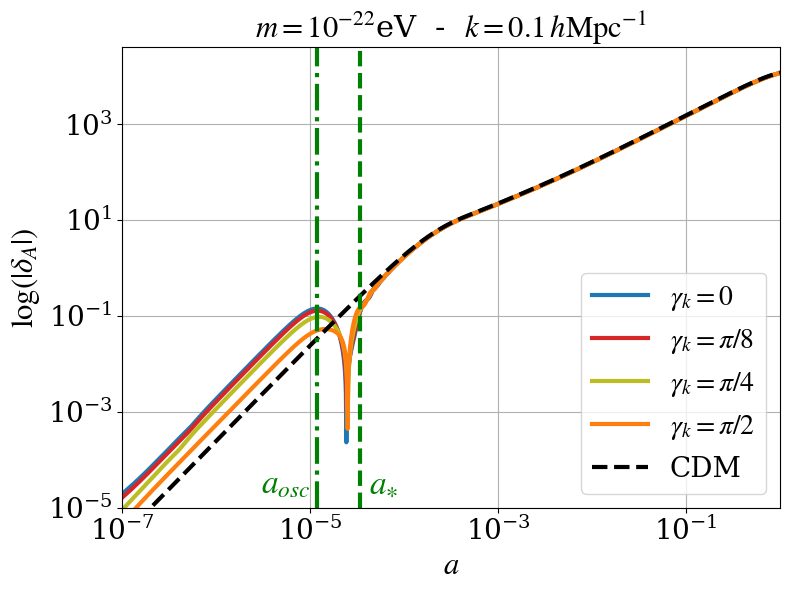

In [10]:
# DELTA  k = 0.1

data_scf = np.loadtxt('../../SFDM_data/delta_scf/delta_scf_m={-25}_k=0.1')

a_scf = data_scf[:,0]  # first column
delta_scf = data_scf[:,1]  # second column

plt.figure(figsize=(8, 6))
for i in range(len(angles)):

    one_k = perts[i]['scalar'][0]
    one_k_lcdm = perturbations_lcdm['scalar'][0]
    delta_vf = one_k['delta_vf']
    delta_lcdm = one_k_lcdm['delta_cdm']
    a = one_k['a']
    a_lcdm = one_k_lcdm['a']
    h = h_planck # get reduced Hubble for conversions to 1/Mpc
    background_z = background_lcdm['z'] # read redshift
    background_a = 1/(1+background_z)
    rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
    mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
    a_equality = interp1d(mat_abundance/rad_abundance, background_a)
    a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)

    background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
    background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
    background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 

    k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
    k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
    k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

    plt.xlabel(r'$a$', size=22)
    plt.ylabel(r'$\log(|\delta_A|)$', size=22)
    plt.loglog(a, np.abs(delta_vf), color=color_angles[i], label=r'$\gamma_{k}=%s$'% str(angles_label[i]), lw=3)
plt.loglog(a_lcdm, np.abs(delta_lcdm), 'k--', label=r'CDM', lw=3)
plt.vlines(k_over_aH, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-5, ymax=1.e5,color='g',linestyle='dashdot',lw=3)
plt.text(0.25*a_osc, 2*1.e-5, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.text(1.25*k_over_aH, 2*1.e-5, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.legend(loc='lower right', fontsize=20)
plt.grid()
plt.ylim(1.e-5, 4.e4)
plt.xlim(1e-7, 1)
plt.title(r'$m = 10^{-22}$eV  -  $k = 0.1 \,h \rm{Mpc}^{-1}$', fontsize=22)
plt.tick_params(axis='both',labelsize=20)
plt.tight_layout()
plt.savefig('../../Figures/delta_A_angles_m=%s_k=01.pdf'%str(mass)[-3:])
plt.show()

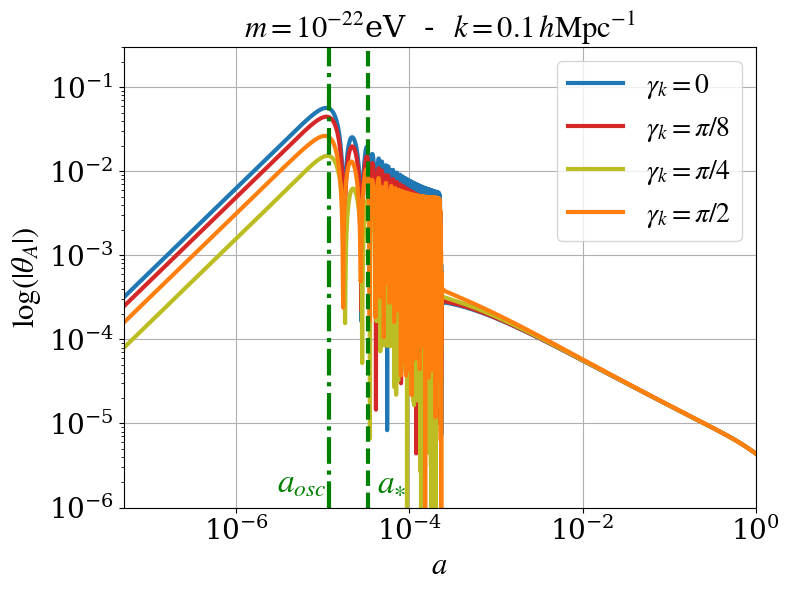

In [11]:
# THETA  k = 0.1
plt.figure(figsize=(8, 6))
for i in range(len(angles)):

    one_k = perts[i]['scalar'][0]
    one_k_lcdm = perturbations_lcdm['scalar'][0]
    theta_vf = one_k['theta_vf']
    a = one_k['a']
    a_lcdm = one_k_lcdm['a']
    h = h_planck # get reduced Hubble for conversions to 1/Mpc
    background_z = background_lcdm['z'] # read redshift
    background_a = 1/(1+background_z)
    rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
    mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
    a_equality = interp1d(mat_abundance/rad_abundance, background_a)
    a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)

    background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
    background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
    background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 

    k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
    k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
    k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

    plt.xlabel(r'$a$', size=22)
    plt.ylabel(r'$\log(|\theta_A|)$', size=22)
    plt.loglog(a, np.abs(theta_vf), color=color_angles[i], label=r'$\gamma_{k}=%s$'% str(angles_label[i]), lw=3)
plt.vlines(k_over_aH, ymin=1.e-6, ymax=1.e2,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-6, ymax=1.e2,color='g',linestyle='dashdot',lw=3)
plt.text(0.25*a_osc, 1.5*1.e-6, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.text(1.25*k_over_aH, 1.5*1.e-6, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.legend(loc='upper right', fontsize=20)
plt.grid()
plt.ylim(1.e-6, 0.3)
plt.xlim(5.e-8, 1)
plt.tick_params(axis='both',labelsize=20)
plt.title(r'$m = 10^{-22}$eV  -  $k = 0.1 \,h \rm{Mpc}^{-1}$', fontsize=22)
plt.tight_layout()
plt.savefig('../../Figures/theta_A_m=%s_k=01.pdf'%str(mass)[-3:])
plt.show()

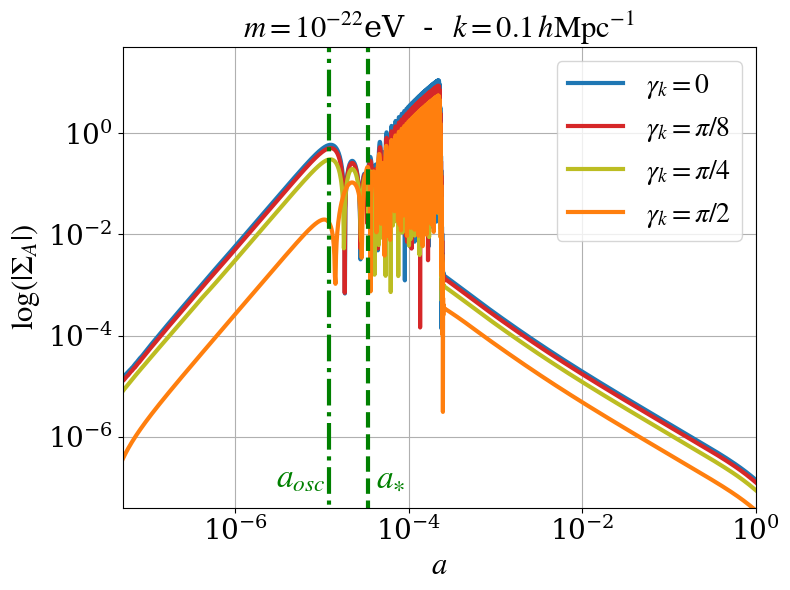

In [12]:
# SHEAR  k = 0.1
plt.figure(figsize=(8, 6))
for i in range(len(angles)):

    one_k = perts[i]['scalar'][0]
    one_k_lcdm = perturbations_lcdm['scalar'][0]
    theta_vf = one_k['shear_vf']
    a = one_k['a']
    a_lcdm = one_k_lcdm['a']
    h = h_planck # get reduced Hubble for conversions to 1/Mpc
    background_z = background_lcdm['z'] # read redshift
    background_a = 1/(1+background_z)
    rad_abundance = background_lcdm['(.)rho_g']/background_lcdm['(.)rho_crit']
    mat_abundance = (background_lcdm['(.)rho_cdm']+background_lcdm['(.)rho_b'])/background_lcdm['(.)rho_crit']
    a_equality = interp1d(mat_abundance/rad_abundance, background_a)
    a_osc = interp1d(background_lcdm['H [1/Mpc]']/(mass * 1.56 * 1.e29), background_a)(1.)

    background_k_over_aH = k/(background_lcdm['H [1/Mpc]']*background_a) # read k/aH = k(1+z)/H
    background_k_over_ma2H = k*np.sqrt(1/(mass* 1.56*10**(29) * background_lcdm['H [1/Mpc]'])*background_z*background_z)
    background_k_over_ma = k/(mass * 1.56* 10**(29) * background_a) 

    k_over_aH = interp1d(background_k_over_aH, background_a)(1.)
    k_over_ma2H = interp1d(background_k_over_ma2H, background_a)
    k_over_ma = interp1d(background_k_over_ma, background_a)(1.)

    plt.xlabel(r'$a$', size=22)
    plt.ylabel(r'$\log(|\Sigma_A|)$', size=22)
    plt.loglog(a, np.abs(theta_vf), color=color_angles[i], label=r'$\gamma_{k}=%s$'% str(angles_label[i]), lw=3)
plt.vlines(k_over_aH, ymin=1.e-8, ymax=1.e2,color='g',linestyle='dashed',lw=3)
plt.vlines(a_osc, ymin=1.e-8, ymax=1.e2,color='g',linestyle='dashdot',lw=3)
plt.text(0.25*a_osc, 1.e-7, r'$a_{osc}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.text(1.25*k_over_aH, 1.e-7, r'$a_{\ast}$', fontdict={'color':'g', 'fontweight':'bold'}, size=24)
plt.legend(loc='upper right', fontsize=20)
plt.grid()
plt.ylim(4.e-8, 5.e1)
plt.xlim(5.e-8, 1)
plt.title(r'$m = 10^{-22}$eV  -  $k = 0.1 \,h \rm{Mpc}^{-1}$', fontsize=22)
plt.tick_params(axis='both',labelsize=20)
plt.tight_layout()
plt.savefig('../../Figures/shear_A_m=%s_k=01.pdf'%str(mass)[-3:])
plt.show()